In [1]:
import os
import boto3

bucket = "retailpulse-team3-ads508"
key = "raw-data/online_retail_II.csv"
local_path = "/home/sagemaker-user/online_retail_II.csv"

s3 = boto3.client("s3")
s3.download_file(bucket, key, local_path)

print("Download complete.")
print("Local file exists:", os.path.exists(local_path))
print("Saved at:", local_path)

Download complete.
Local file exists: True
Saved at: /home/sagemaker-user/online_retail_II.csv


In [2]:
import pandas as pd

df = pd.read_csv(local_path, encoding="ISO-8859-1")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


## Know about our data 

In [3]:
print("Shape:", df.shape)

Shape: (541910, 8)


In [4]:
print(df.columns)

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')


In [5]:
print(df.dtypes)

Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


## Check for missing values

This is one of the main exploration tasks.

In [7]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

## Show missing value percentage

In [8]:
(df.isnull().mean() * 100).sort_values(ascending=False)

Customer ID    24.926648
Description     0.268310
StockCode       0.000000
Invoice         0.000000
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Country         0.000000
dtype: float64

## Check for duplicate rows

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


## Check summary statistics

In [10]:
df.describe()

,Quantity,Price,Customer ID
count,541910.000000,541910.000000,406830.000000
mean,9.552234,4.611138,15287.684160
std,218.080957,96.759765,1713.603074
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


## Convert InvoiceDate to datetime

In [11]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

In [12]:
df["InvoiceDate"].head()

0   2010-01-12 08:26:00
1   2010-01-12 08:26:00
2   2010-01-12 08:26:00
3   2010-01-12 08:26:00
4   2010-01-12 08:26:00
Name: InvoiceDate, dtype: datetime64[ns]

## Create useful time-based fields

In [13]:
df["PurchaseYear"] = df["InvoiceDate"].dt.year
df["PurchaseMonth"] = df["InvoiceDate"].dt.month
df["PurchaseDay"] = df["InvoiceDate"].dt.day

## Identify canceled transactions

In [15]:
cancelled_count = df["Invoice"].astype(str).str.startswith("C").sum()
print("Cancelled transactions:", cancelled_count)

Cancelled transactions: 9288


## Check for invalid quantity and price values

In [16]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())

Quantity <= 0: 10624


## Check country distribution

In [20]:
df["Country"].value_counts().head(10)

Country
United Kingdom    495478
Germany             9495
France              8558
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

## Check most frequent products

In [21]:
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
ASSORTED COLOUR BIRD ORNAMENT         1501
SET OF 3 CAKE TINS PANTRY DESIGN      1473
PACK OF 72 RETROSPOT CAKE CASES       1385
LUNCH BAG  BLACK SKULL.               1350
NATURAL SLATE HEART CHALKBOARD        1280
Name: count, dtype: int64

## Check most frequent customers

In [23]:
df["Customer ID"].value_counts().head(10)

Customer ID
17841.0    7983
14911.0    5903
14096.0    5128
12748.0    4642
14606.0    2782
15311.0    2491
14646.0    2085
13089.0    1857
13263.0    1677
14298.0    1640
Name: count, dtype: int64

## Create a transaction value field

In [26]:
df["TotalTransactionValue"] = df["Quantity"] * df["Price"]
df[["Quantity", "Price", "TotalTransactionValue"]].head()

,Quantity,Price,TotalTransactionValue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Analyze monthly sales trend

In [27]:
monthly_sales = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalTransactionValue"].sum()
monthly_sales

InvoiceDate
2010-01     58635.56
2010-02     46207.28
2010-03     45620.46
2010-05     31383.95
2010-06     53860.18
2010-07     45059.05
2010-08     44189.84
2010-09     52532.13
2010-10     57404.91
2010-12     17240.92
2011-01    257436.33
2011-02    242487.95
2011-03    262517.65
2011-04    367045.11
2011-05    312531.66
2011-06    327010.65
2011-07    404720.82
2011-08    342395.25
2011-09    288498.77
2011-10    287074.15
2011-11    388681.41
2011-12    215762.54
Freq: M, Name: TotalTransactionValue, dtype: float64

## Make visualizations

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

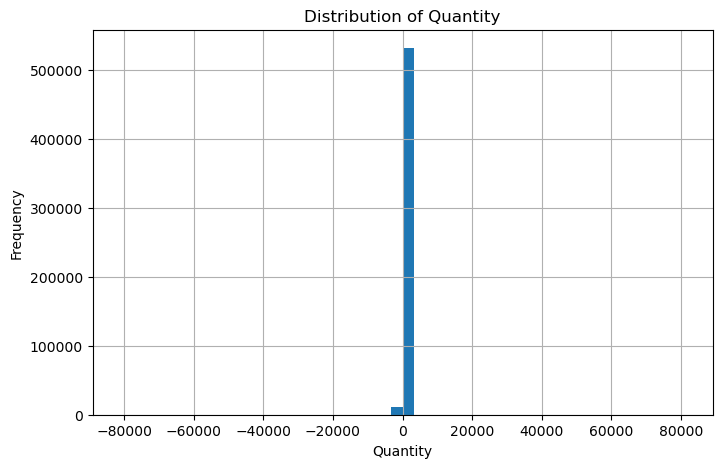

In [29]:
# Quantity distribution

plt.figure(figsize=(8,5))
df["Quantity"].hist(bins=50)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.show()

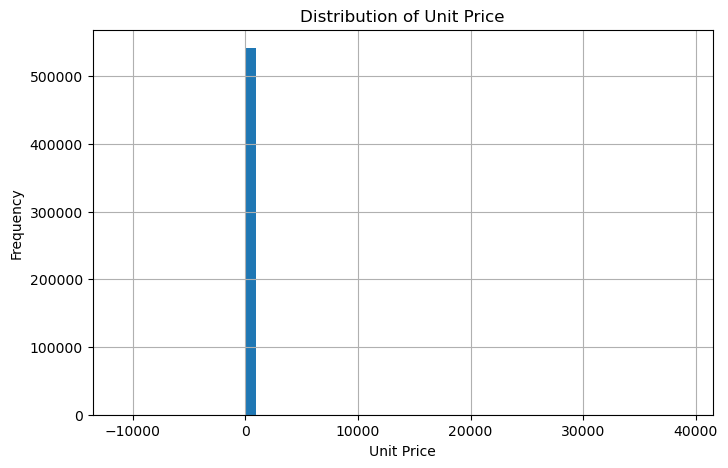

In [31]:
# Plot unit price distribution
plt.figure(figsize=(8,5))
df["Price"].hist(bins=50)
plt.title("Distribution of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

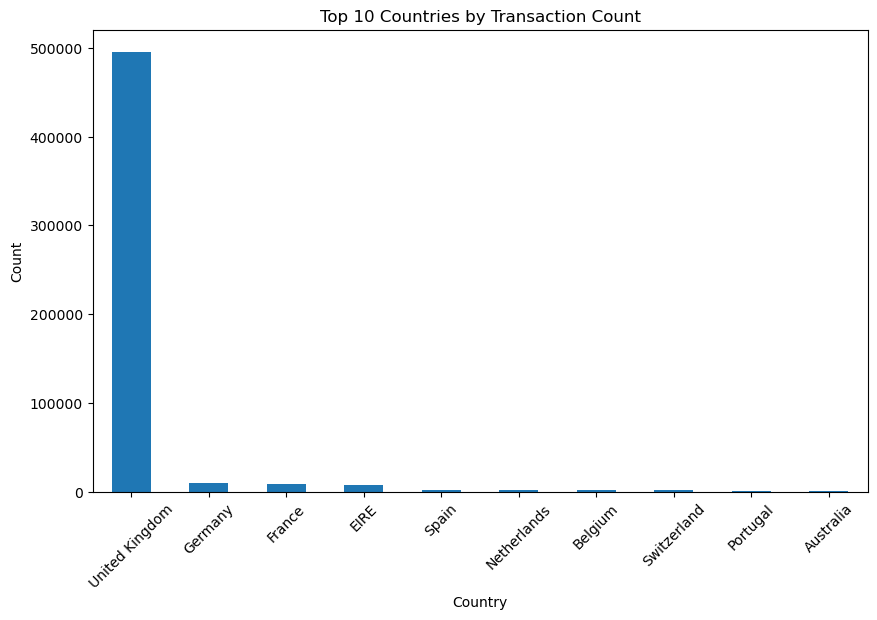

In [34]:
# Plot top countries
abstop_countries = df["Country"].value_counts().head(10)

plt.figure(figsize=(10,6))
abstop_countries.plot(kind="bar")
plt.title("Top 10 Countries by Transaction Count")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

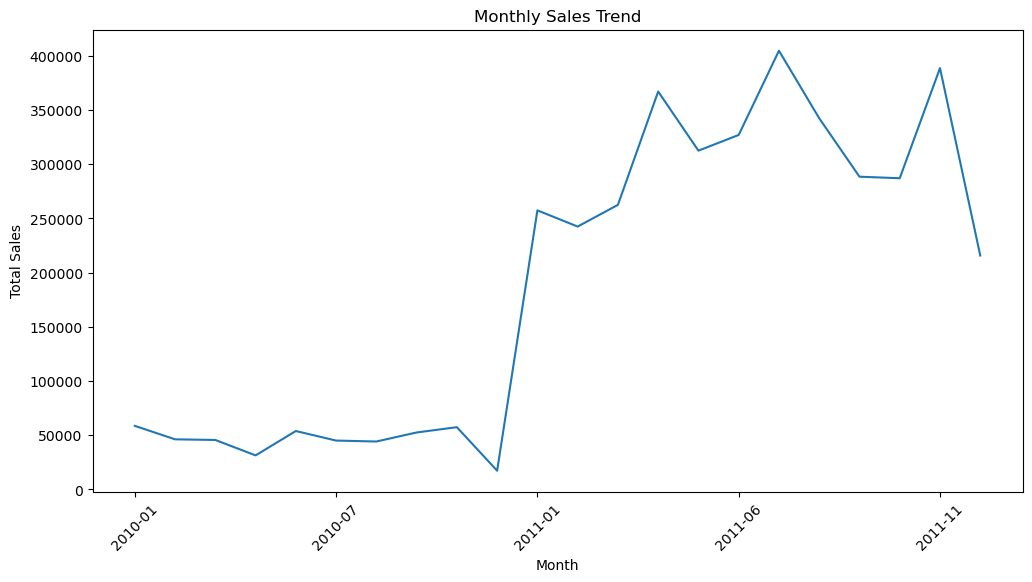

In [35]:
# plot monthly sales trend

monthly_sales_plot = df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalTransactionValue"].sum()
monthly_sales_plot.index = monthly_sales_plot.index.astype(str)

plt.figure(figsize=(12,6))
monthly_sales_plot.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

## Create a cleaned dataset

In [38]:
df_clean = df.copy()

df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C", na=False)]
df_clean = df_clean[df_clean["Quantity"] > 0]
df_clean = df_clean[df_clean["Price"] > 0]
df_clean = df_clean.drop_duplicates()

In [39]:
clean_local_path = "/home/sagemaker-user/cleaned_retail_data.csv"
df_clean.to_csv(clean_local_path, index=False)

print("Cleaned file saved locally:", clean_local_path)

Cleaned file saved locally: /home/sagemaker-user/cleaned_retail_data.csv


In [40]:
s3.upload_file(
    clean_local_path,
    bucket,
    "processed-data/cleaned_retail_data.csv"
)

print("Cleaned file uploaded to S3")

Cleaned file uploaded to S3
